# BMW Price Prediction & Classification using Machine Learning

## Problem Statement
The goal of this project is to analyze BMW used car data and build machine learning models that classify vehicles into price categories based on features such as mileage, engine size, fuel type, and transmission.

The project includes data preprocessing, exploratory data analysis, model training, and performance evaluation.

## Objective

The objective of this project is to build a machine learning model that predicts the **price category of BMW vehicles** based on various features such as model, year, mileage, fuel type, transmission type, engine size, and other attributes.

Machine learning algorithms are used to analyze the dataset, identify patterns in vehicle specifications, and classify BMW cars into **High-price and Low-price categories**.

## Tools Used

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn
* Scikit-learn


## Dataset Description

The dataset contains information about **BMW used cars and their specifications**.
Each row represents a BMW vehicle with details about its model, technical features, and price.

The dataset is used to analyze how different factors influence the price of BMW vehicles and to build a machine learning model that classifies cars into **price categories (High / Low)**.

**Important features in the dataset include:**

* **Model** – BMW car model (e.g., 1 Series, 3 Series, X5)
* **Year** – Manufacturing year of the vehicle
* **Transmission** – Type of transmission (Manual, Automatic, Semi-Automatic)
* **Mileage** – Distance the car has been driven (in miles/km)
* **Fuel Type** – Type of fuel used (Petrol, Diesel, Hybrid)
* **Tax** – Annual road tax of the vehicle
* **MPG** – Miles per gallon (fuel efficiency)
* **Engine Size** – Engine capacity of the vehicle
* **Price** – Market price of the vehicle

For this project, a new variable called **Price_Class** is created to classify cars into **High-price and Low-price categories**, which will be predicted using machine learning algorithms.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [30]:
df = pd.read_csv("bmw.csv")

In [31]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5 Series,2014,11200,Automatic,67068,Diesel,125,57.6,2.0
1,6 Series,2018,27000,Automatic,14827,Petrol,145,42.8,2.0
2,5 Series,2016,16000,Automatic,62794,Diesel,160,51.4,3.0
3,1 Series,2017,12750,Automatic,26676,Diesel,145,72.4,1.5
4,7 Series,2014,14500,Automatic,39554,Diesel,160,50.4,3.0


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10781 entries, 0 to 10780
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         10781 non-null  object 
 1   year          10781 non-null  int64  
 2   price         10781 non-null  int64  
 3   transmission  10781 non-null  object 
 4   mileage       10781 non-null  int64  
 5   fuelType      10781 non-null  object 
 6   tax           10781 non-null  int64  
 7   mpg           10781 non-null  float64
 8   engineSize    10781 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 758.2+ KB


In [33]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000,10781.000000
mean,2017.078935,22733.408867,25496.986550,131.702068,56.399035,2.167767
std,2.349038,11415.528189,25143.192559,61.510755,31.336958,0.552054
min,1996.000000,1200.000000,1.000000,0.000000,5.500000,0.000000
25%,2016.000000,14950.000000,5529.000000,135.000000,45.600000,2.000000
50%,2017.000000,20462.000000,18347.000000,145.000000,53.300000,2.000000
75%,2019.000000,27940.000000,38206.000000,145.000000,62.800000,2.000000
max,2020.000000,123456.000000,214000.000000,580.000000,470.800000,6.600000


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the distribution of variables and identify relationships between features.

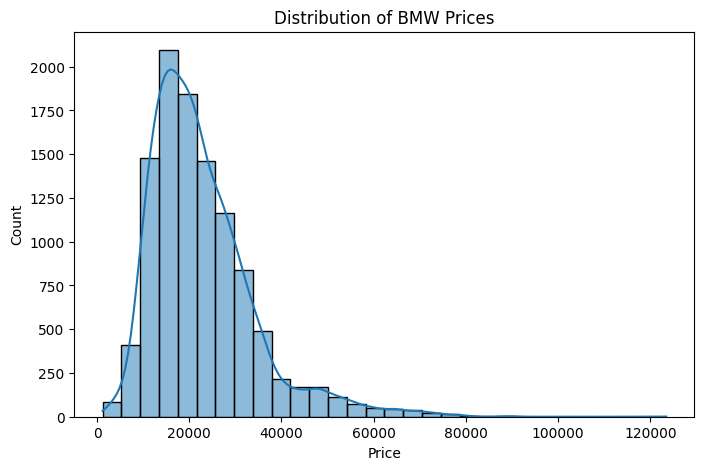

In [34]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of BMW Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

### Correlation Analysis

Correlation analysis helps identify relationships between numerical variables in the dataset. Strong correlations may indicate important features for predicting price.

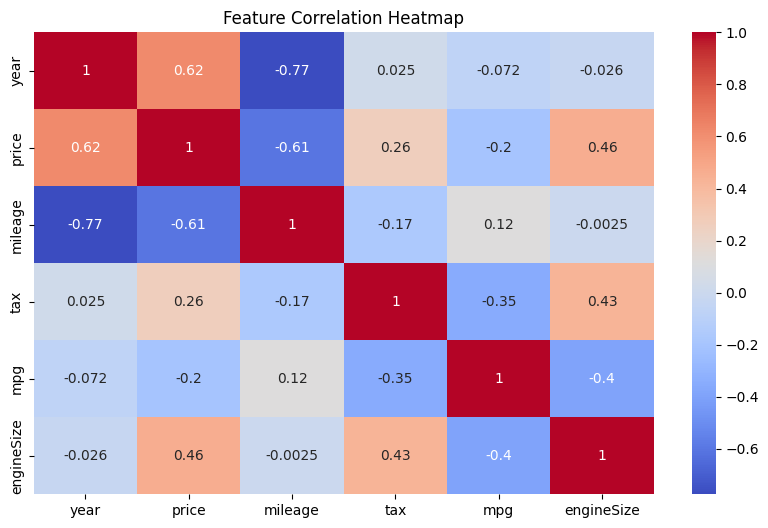

In [35]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

### Observations

The heatmap shows that engine size and year have a strong relationship with vehicle price. Mileage tends to negatively correlate with price, indicating that higher mileage vehicles are generally cheaper.

In [36]:
df.isnull().sum()

model           0
year            0
price           0
transmission    0
mileage         0
fuelType        0
tax             0
mpg             0
engineSize      0
dtype: int64

In [37]:
df = df.drop_duplicates()

In [38]:
df["Price_Class"] = pd.qcut(df["price"], q=3, labels=["Low","Medium","High"])

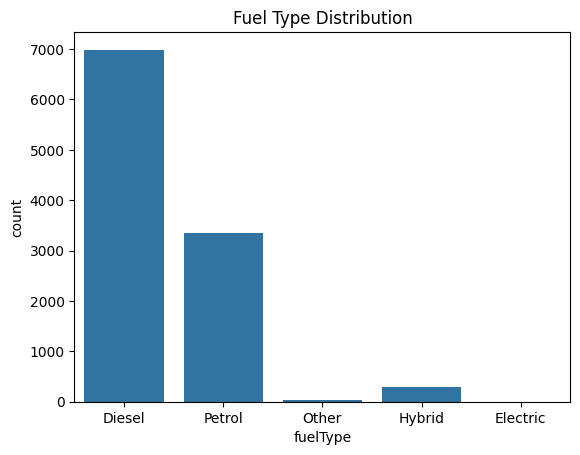

In [39]:
sns.countplot(x="fuelType", data=df)
plt.title("Fuel Type Distribution")
plt.show()

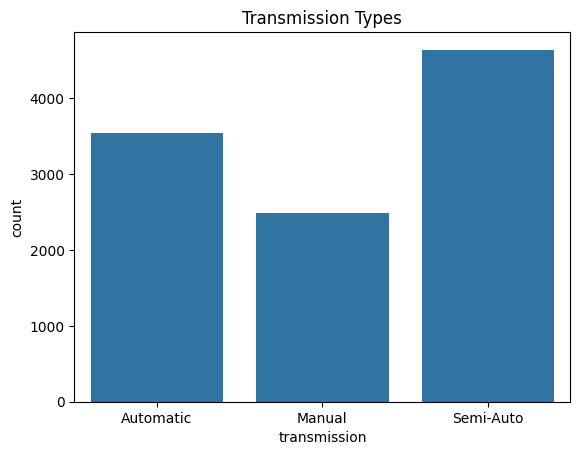

In [40]:
sns.countplot(x="transmission", data=df)
plt.title("Transmission Types")
plt.show()

In [41]:
y = df["Price_Class"]
X = df.drop(["price","Price_Class"], axis=1)

In [42]:
X = pd.get_dummies(X, drop_first=True)

## Model Training

In this section, multiple machine learning models are trained and evaluated to determine which model performs best for BMW price classification.

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Train Logistic Regression

In [44]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7848101265822784


C:\Users\KIIT0001\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Train Decision Tree

In [45]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.8696671354899203


Random Forest

In [49]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.8884200656352556


### Cross Validation

Cross validation is used to evaluate the model across multiple data splits to ensure that the model generalizes well and does not overfit.

In [55]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf, X, y, cv=5)
print("Cross Validation Scores:", cv_scores)
print("Average CV Score:", cv_scores.mean())

Cross Validation Scores: [0.89451477 0.85841538 0.90764182 0.90670417 0.86585366]
Average CV Score: 0.8866259590865951


## Model Comparison

The performance of different machine learning models is compared using accuracy scores.

In [50]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.784810
1,Decision Tree,0.869667
2,Random Forest,0.888420


### Confusion Matrix

The confusion matrix shows how well the classification model predicts each price category.

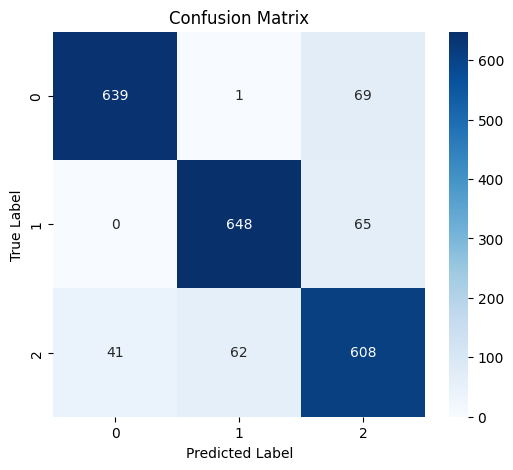

In [56]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.92      0.91      0.92       709
         Low       0.92      0.90      0.91       713
      Medium       0.82      0.85      0.84       711

    accuracy                           0.89      2133
   macro avg       0.89      0.89      0.89      2133
weighted avg       0.89      0.89      0.89      2133



## Feature Importance

Feature importance helps identify which variables contribute most to the prediction of BMW price categories.

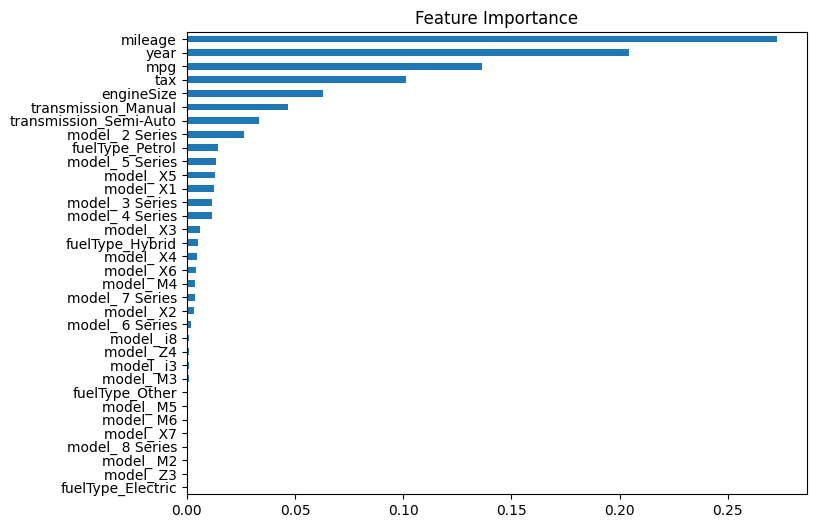

In [57]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()

### Insights from Feature Importance

The feature importance plot shows that engine size, vehicle age, and mileage are among the most influential factors affecting BMW prices.

Larger engine sizes and newer vehicles generally correspond to higher price categories.

## Conclusion

In this project, machine learning models were used to classify BMW vehicles into price categories.

Random Forest achieved the highest accuracy among the tested models. Important features influencing BMW price include engine size, vehicle age, and mileage.

This project demonstrates how machine learning can be applied to automobile pricing analysis.